In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv1D, AveragePooling1D
import tensorflow as tf
from sklearn import metrics

plt.rcParams['font.size'] = 14

2026-03-17 15:40:53.529988: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-17 15:40:53.540858: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 15:40:53.874352: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-17 15:40:55.176746: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

# 2.
Study the CNN performance by changing the amplitude A of the input patterns to analyze the effect of signal-to-noise ratio.

In [2]:
# --- Parametri generali dei dati ---
N = 10000       # numero di samples
L = 60          # lunghezza di ciascun time series
Z = 12          # numero di bins del pattern
DX = 50         # rumore
bias = 5        # bias
amp_list = [100, 200, 500, 800]  # ampiezze dei pattern
os.makedirs("DATA", exist_ok=True)

# Parametri CNN
NCONV = 1
NF = 5
BATCH_SIZE = 200
EPOCHS = 150
n_class = 3

# Seed per riproducibilità
np.random.seed(12345)
tf.random.set_seed(12345)

# Label e cmap per confusion matrix
LABELS = ["absent", "positive", "negative"]
cmap = "GnBu"

In [3]:
# --- Funzioni ---
jump = lambda drift, stdev: int(np.random.normal(drift, stdev))
def pattern(i, z, a): return int(a * np.sin((np.pi*i)/z))

def show_confusion_matrix(validations, predictions, label="Model"):
    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6,5))
    seaborn.heatmap(matrix, xticklabels=LABELS, yticklabels=LABELS,
                    annot=True, fmt='d', linecolor='white', linewidths=1, cmap=cmap)
    plt.title(f"{label} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
def create_model(input_shape, reg=tf.keras.regularizers.l2(0.2)):
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05)
    model = Sequential()
    if NCONV==1:
        model.add(Conv1D(filters=NF, kernel_size=11, activation='relu',
                         kernel_initializer=ini, kernel_regularizer=reg,
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
    elif NCONV==2:
        model.add(Conv1D(filters=NF, kernel_size=11, activation='relu',
                         kernel_initializer=ini, kernel_regularizer=reg,
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))
    model.add(Dense(n_class, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def preprocess_data(x, y, train_frac=0.8):
    # one-hot encoding
    y_oh = np.zeros((len(y), n_class))
    for i in range(len(y)):
        y_oh[i][y[i]] = 1.
    # split train/val
    N_train = int(train_frac * len(x))
    x_train, y_train = x[:N_train], y_oh[:N_train]
    x_val, y_val = x[N_train:], y_oh[N_train:]
    # rescale
    std_mean = x_train.std(axis=1).mean()
    x_train = (x_train - x_train.mean(axis=1)[:,None]) / std_mean
    x_val = (x_val - x_val.mean(axis=1)[:,None]) / std_mean
    # reshape
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val = x_val.reshape(x_val.shape[0], L, 1)
    return x_train, y_train, x_val, y_val


def show_history(fit, label="Model"):
    """Mostra i grafici di Accuracy e Loss"""
    fig, AX = plt.subplots(1, 2, figsize=(12,5))
    
    # Accuracy
    ax = AX[0]
    ax.plot(fit.history['accuracy'], "b", label="train")
    ax.plot(fit.history['val_accuracy'], "r--", label="valid.")
    ax.axhline(1/n_class, color='gray', linestyle=':', label="random chance")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.set_title(f"{label} - Accuracy")
    ax.legend()
    
    # Loss
    ax = AX[1]
    ax.plot(fit.history['loss'], "b", label="train")
    ax.plot(fit.history['val_loss'], "r--", label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.set_title(f"{label} - Loss")
    ax.legend()
    
    plt.show()
    
    



===== Dataset e CNN con ampiezza A=100 =====


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-17 15:40:56.167498: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


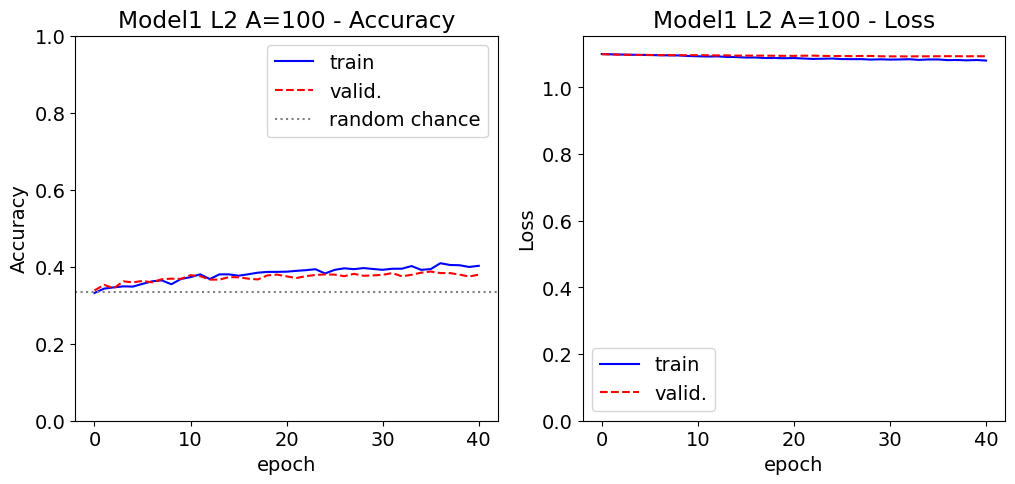

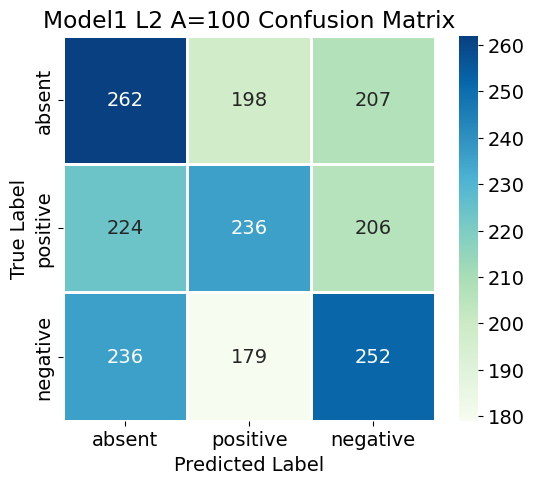

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


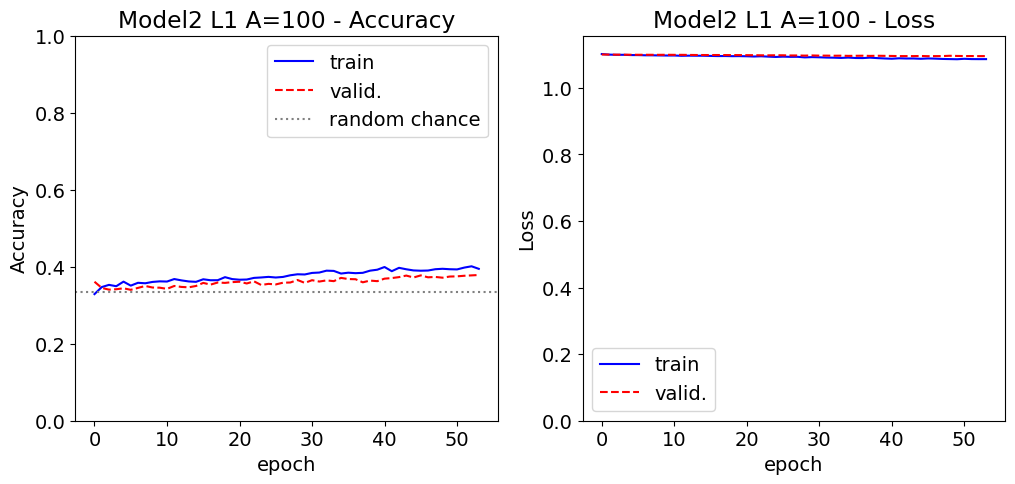

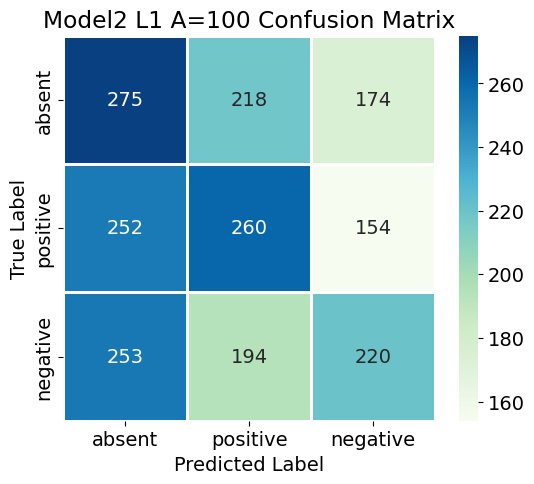

Validation accuracy Model1 L2 A=100: 0.380
Validation accuracy Model2 L1 A=100: 0.379

===== Dataset e CNN con ampiezza A=200 =====


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


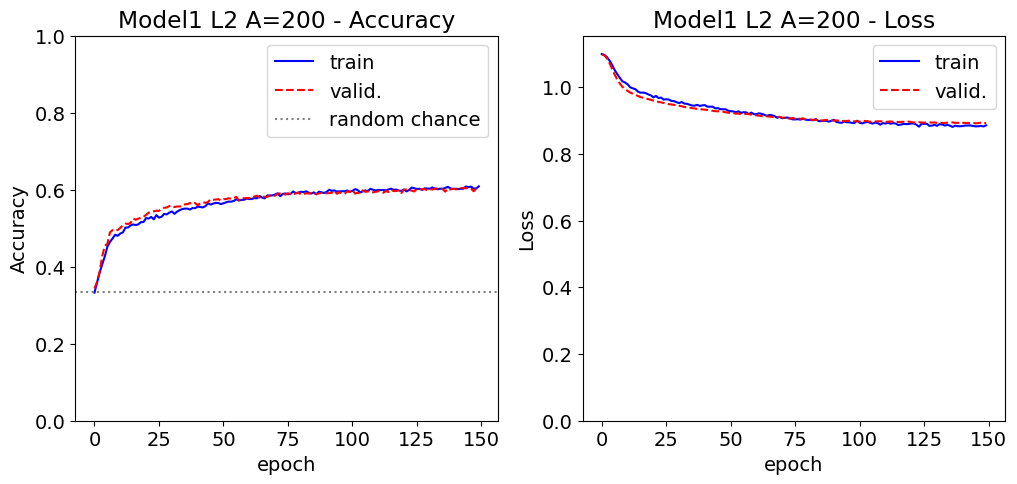

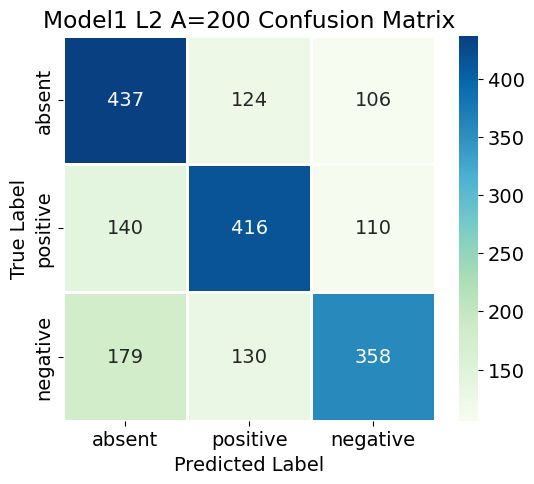

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


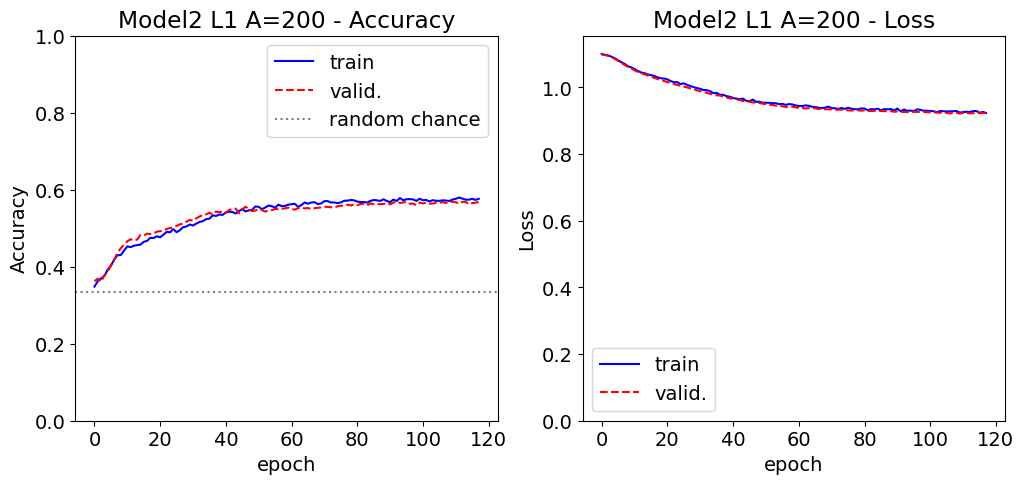

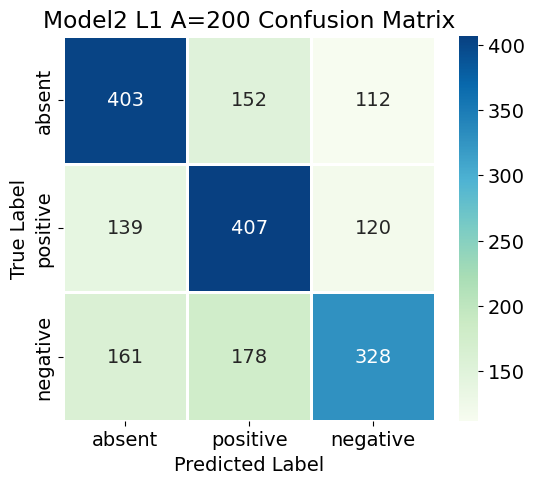

Validation accuracy Model1 L2 A=200: 0.603
Validation accuracy Model2 L1 A=200: 0.568

===== Dataset e CNN con ampiezza A=500 =====


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


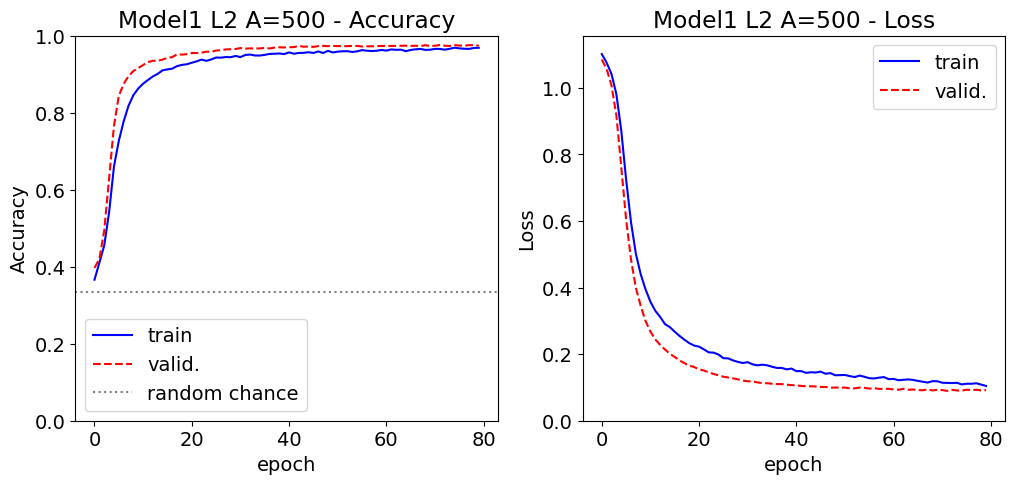

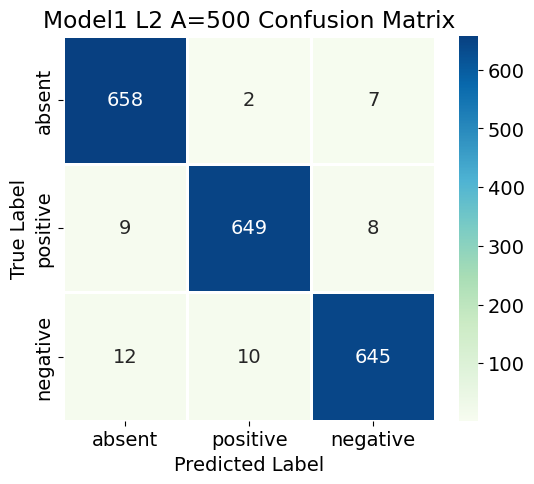

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


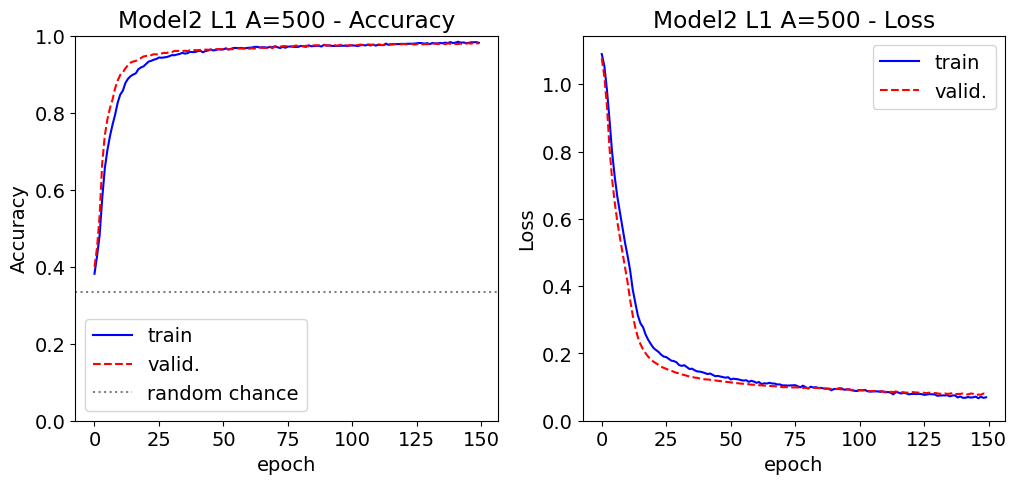

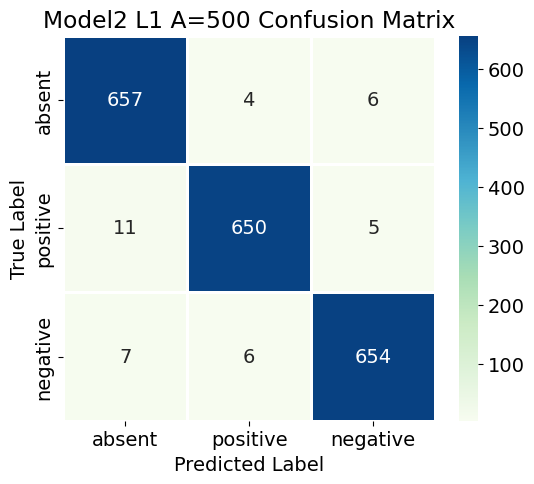

Validation accuracy Model1 L2 A=500: 0.974
Validation accuracy Model2 L1 A=500: 0.980

===== Dataset e CNN con ampiezza A=800 =====


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


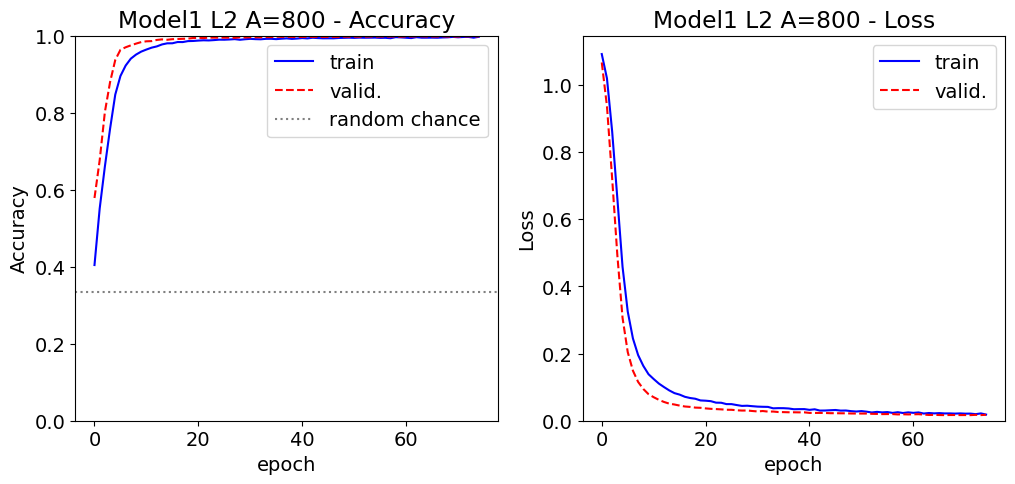

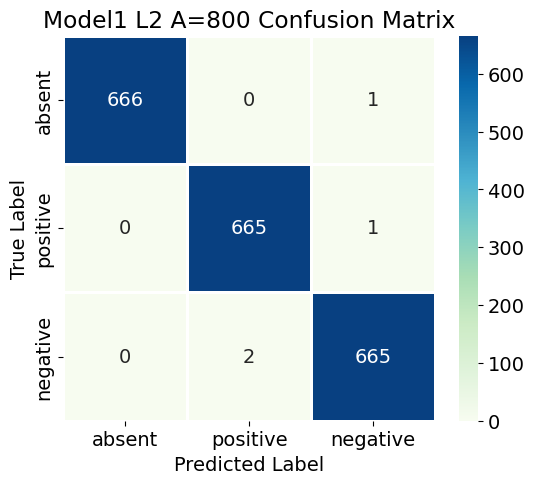

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


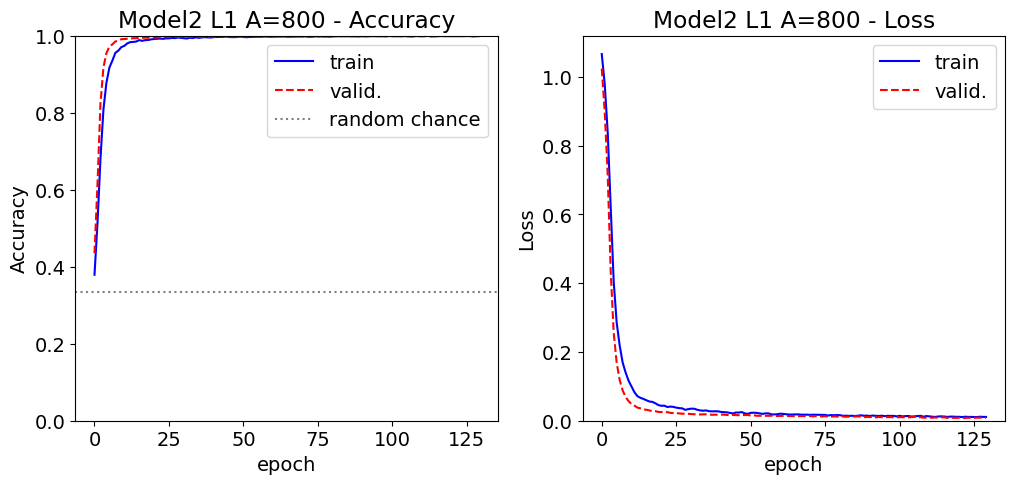

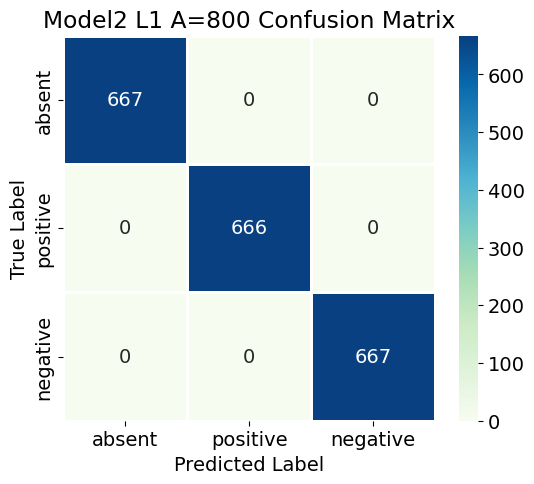

Validation accuracy Model1 L2 A=800: 0.998
Validation accuracy Model2 L1 A=800: 0.999


In [4]:
# --- Loop sulle ampiezze ---
for A in amp_list:
    print(f"\n===== Dataset e CNN con ampiezza A={A} =====")
    
    # nomi file
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'
    fnamex = 'DATA/x_' + str0
    fnamey = 'DATA/y_' + str0
    
    # --- Genera dati ---
    x = [[0] * L for _ in range(N)]
    y = [0] * N

    for i in range(N):
        if i > 0:
            x[i][0] = x[i-1][-1] + jump(bias, DX)
        for j in range(1, L):
            x[i][j] = x[i][j-1] + jump(bias, DX)
        y[i] = i % 3
        if y[i] > 0:
            j0 = np.random.randint(0, L-1-Z)
            sign = 3 - 2*y[i]  # +1 for class 1, -1 for class 2
            for j in range(Z):
                x[i][j0 + j] += sign * pattern(j, Z, A)

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=int)

    #salva i dataset su file
    np.savetxt(fnamex, x, fmt="%d")
    np.savetxt(fnamey, y, fmt="%d")
    
    # one-hot encoding
    y_oh = np.zeros((len(y), n_class))
    for i in range(len(y)):
        y_oh[i][y[i]] = 1.
    
    # split train/val
    N_train = int(0.8*len(x))
    x_train, y_train = x[:N_train], y_oh[:N_train]
    x_val, y_val = x[N_train:], y_oh[N_train:]
    
    # rescale con std media del train
    std_mean = x_train.std(axis=1).mean()
    x_train = (x_train - x_train.mean(axis=1)[:, None]) / std_mean
    x_val = (x_val - x_val.mean(axis=1)[:, None]) / std_mean
    
    # reshape per CNN
    x_train = x_train.reshape(N_train, L, 1)
    x_val = x_val.reshape(len(x)-N_train, L, 1)
    
    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=8,
        restore_best_weights=True
    )
    
    # --- Modello 1: L2 ---
    reg_l2 = tf.keras.regularizers.l2(0.01)

    model1 = create_model((L,1), reg_l2)

    fit1 = model1.fit(x_train, y_train,  batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(x_val, y_val),
                      verbose=0,callbacks=[early])

    # predizione
    y_pred_val1 = np.argmax(model1.predict(x_val), axis=1)
    y_val_true = np.argmax(y_val, axis=1)

    show_history(fit1, label=f"Model1 L2 A={A}")
    show_confusion_matrix(y_val_true, y_pred_val1, label=f"Model1 L2 A={A}")


    # --- Modello 2: L1 ---
    reg_l1 = tf.keras.regularizers.l1(0.001)

    model2 = create_model((L,1), reg_l1)

    fit2 = model2.fit(x_train,  y_train,  batch_size=BATCH_SIZE,  epochs=EPOCHS,  validation_data=(x_val, y_val),
                      verbose=0,callbacks=[early])

    # predizione
    y_pred_val2 = np.argmax(model2.predict(x_val), axis=1)

    show_history(fit2, label=f"Model2 L1 A={A}")
    show_confusion_matrix(y_val_true, y_pred_val2, label=f"Model2 L1 A={A}")


    # stampa accuracy finale
    print(f"Validation accuracy Model1 L2 A={A}: {fit1.history['val_accuracy'][-1]:.3f}")
    print(f"Validation accuracy Model2 L1 A={A}: {fit2.history['val_accuracy'][-1]:.3f}")

# 3.

Investigate whether applying L1, L2, or mixed L1-L2 regularization improves model performance by varying the regularization parameter $\lambda$.

In [27]:
#A= 500 ragionevole 

A= 500 

lambda_list = [0, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.5]

# Strutture per salvare i risultati
accs_l2  = []
accs_l1  = []
accs_mix = []

best_models = {}

for lam in lambda_list:
    print(f"\n===== lambda = {lam} =====")
    
    # Definisci i tre regolarizzatori
    if lam == 0:
        reg_l2  = None
        reg_l1  = None
        reg_mix = None
    else:
        reg_l2  = tf.keras.regularizers.l2(lam)
        reg_l1  = tf.keras.regularizers.l1(lam)
        reg_mix = tf.keras.regularizers.l1_l2(l1=lam/2, l2=lam/2)
    
    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=8, restore_best_weights=True
    )
    
    results = {}

    # Addestra i tre modelli
    for reg, name in [(reg_l2,'L2'), (reg_l1,'L1'), (reg_mix,'L1_L2')]:
        model = create_model((L,1), reg)
        fit = model.fit(x_train, y_train,
                        batch_size=200, epochs=150,
                        validation_data=(x_val, y_val),
                        verbose=0, callbacks=[early])
        
        best_acc = max(fit.history['val_accuracy'])
        results[name] = best_acc
        
        print(f"  {name}: best val_accuracy = {best_acc:.3f}")
        
        best_models[(name, lam)] = model
        
    accs_l2.append(results['L2'])
    accs_l1.append(results['L1'])
    accs_mix.append(results['L1_L2'])


===== lambda = 0 =====
  L2: best val_accuracy = 0.999
  L1: best val_accuracy = 0.998
  L1_L2: best val_accuracy = 0.999

===== lambda = 1e-05 =====
  L2: best val_accuracy = 0.999
  L1: best val_accuracy = 0.998
  L1_L2: best val_accuracy = 0.999

===== lambda = 0.0001 =====
  L2: best val_accuracy = 0.999
  L1: best val_accuracy = 1.000
  L1_L2: best val_accuracy = 1.000

===== lambda = 0.001 =====
  L2: best val_accuracy = 0.997
  L1: best val_accuracy = 1.000
  L1_L2: best val_accuracy = 1.000

===== lambda = 0.01 =====
  L2: best val_accuracy = 1.000
  L1: best val_accuracy = 0.997
  L1_L2: best val_accuracy = 0.999

===== lambda = 0.1 =====
  L2: best val_accuracy = 1.000
  L1: best val_accuracy = 0.971
  L1_L2: best val_accuracy = 0.999

===== lambda = 0.2 =====
  L2: best val_accuracy = 0.999
  L1: best val_accuracy = 0.982
  L1_L2: best val_accuracy = 0.997

===== lambda = 0.5 =====
  L2: best val_accuracy = 1.000
  L1: best val_accuracy = 0.359
  L1_L2: best val_accuracy = 

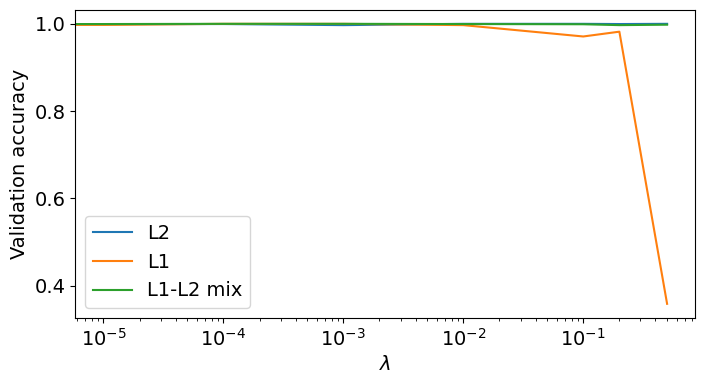

In [33]:
plt.figure(figsize=(8,4))
plt.plot(lambda_list,accs_l2,label='L2')
plt.plot(lambda_list,accs_l1,label='L1')
plt.plot(lambda_list,accs_mix,label='L1-L2 mix')
plt.legend()
plt.xscale('log') 
plt.xlabel('$\lambda$')
plt.ylabel('Validation accuracy')
plt.show()

## 3.1


The performance is optimized for an intermediate value of $\lambda$.
For very small $\lambda$ (or $\lambda$ = 0), the model tends to overfit, while for large $\lambda$ the model underfits due to excessive regularization.
The best validation accuracy is obtained around $\lambda$ ≈ 0.01 ?????????, confirming that a moderate regularization improves generalization.

## 3.2
Visualize the first convolutional layer filters to compare interpretability and sparsity between unregularized and regularized models.

In [22]:
def Show_weights(model, l=0, label="model"):
    
    w = model.layers[l].get_weights()[0]  # weights
    b = model.layers[l].get_weights()[1]  # bias
    
    print(f"{label} - layer {l} weights shape:", w.shape)

    wT = w.T
    M = len(wT)

    colors = plt.cm.tab10(np.linspace(0,1,M))  # colori automatici

    fig, AX = plt.subplots(1,2, figsize=(12,4.4))
    
    # ---- FILTRI ----
    ax = AX[0]
    ax.axhline(0, c="k")
    
    for i in range(M):
        ax.plot(wT[i][0], "-", color=colors[i], marker='o', label=f"{i}")
    
    ax.set_title(label + f': filters (layer {l})')
    ax.set_xlabel('index')
    ax.legend()
    
    # ---- BIAS ----
    ax = AX[1]
    ax.axhline(0, c="k")
    
    for i in range(M):
        ax.plot(i, b[i], marker='o', color=colors[i])
    
    ax.set_title(label + f': bias (layer {l})')
    ax.set_xlabel('filter index')
    
    plt.tight_layout()
    plt.show()

In [31]:
#for name in ['L2', 'L1', 'L1_L2']:
 #   for lam in lambda_list:
  #      model = best_models[(name, lam)]
   #     Show_weights(model, 0, f"{name}, lambda={lam}")

No reg L2, lambda=0 - layer 0 weights shape: (11, 1, 5)


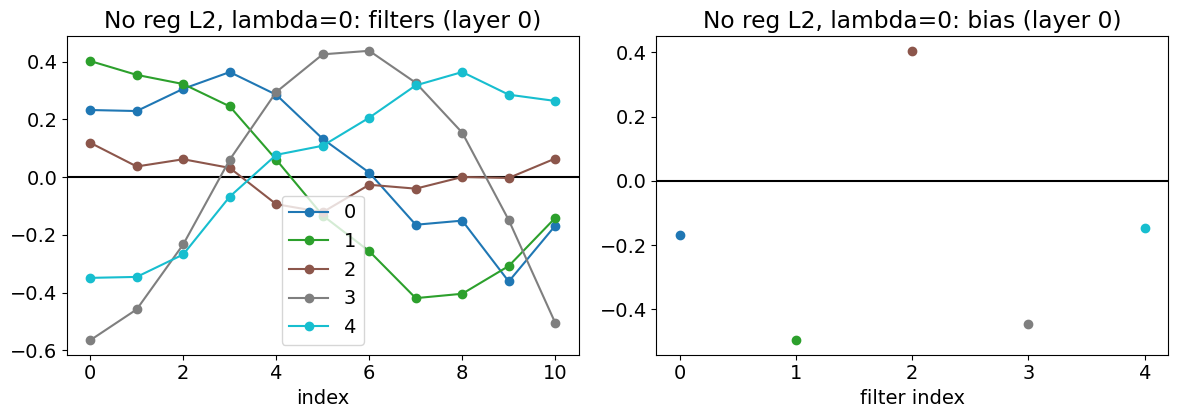

L2, lambda=0.01 - layer 0 weights shape: (11, 1, 5)


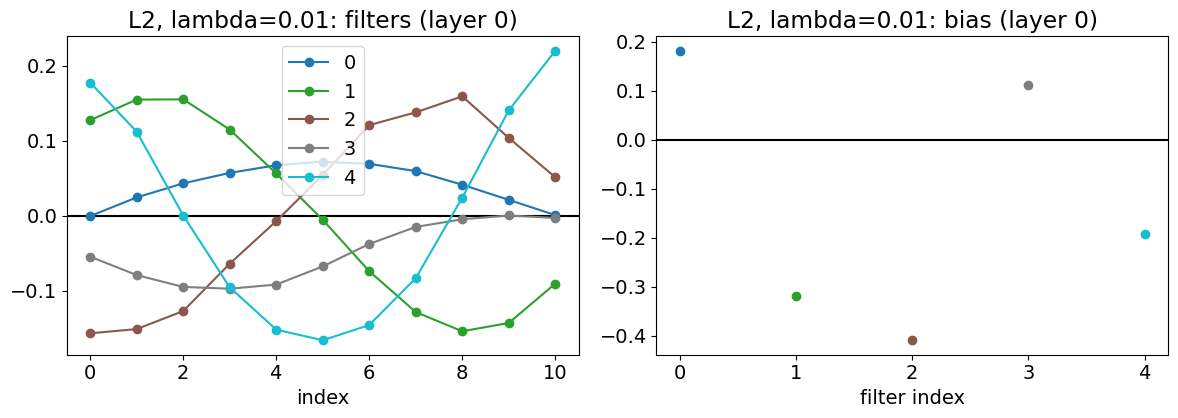

L1, lambda=0.01 - layer 0 weights shape: (11, 1, 5)


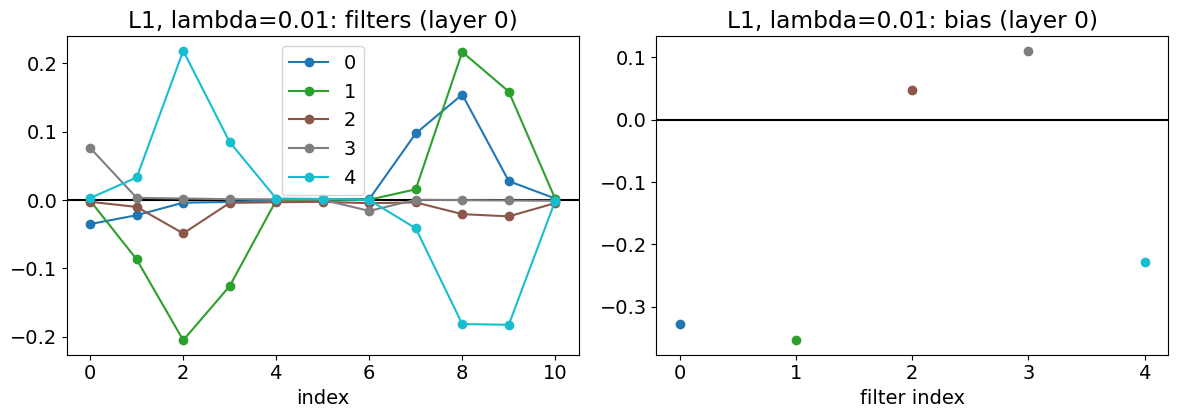

L1_L2, lambda=0.01 - layer 0 weights shape: (11, 1, 5)


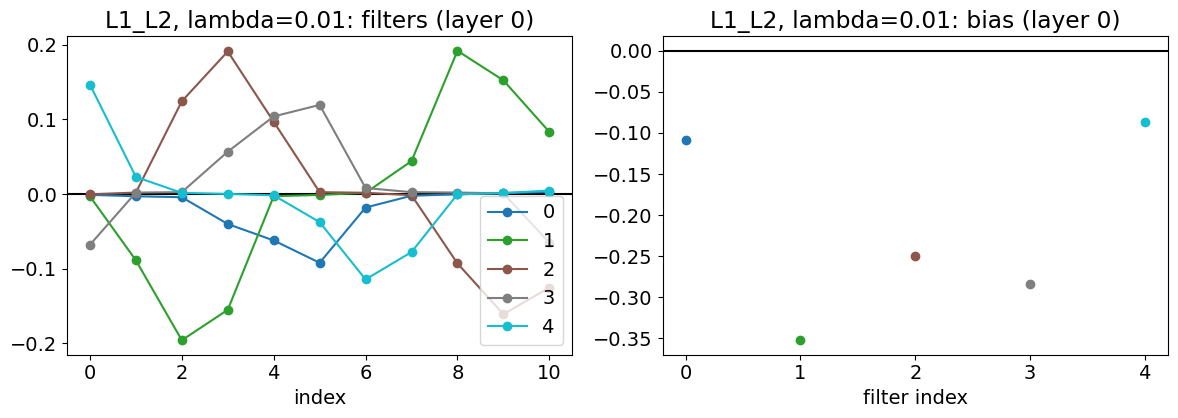

In [32]:
best_lambda = 0.01

selected_models = [
    ("No reg L2", 0),       # modello senza regolarizzazione, chiave 'L2', lambda=0
    ("L2", best_lambda),
    ("L1", best_lambda),
    ("L1_L2", best_lambda)
]

# mostra filtri per ciascun modello selezionato
for label, lam in selected_models:
    if label.startswith("No reg"):
        model = best_models[("L2", lam)]  # usa 'L2' perché è la chiave salvata
    else:
        model = best_models[(label, lam)]
    Show_weights(model, l=0, label=f"{label}, lambda={lam}")

The visualization of the weights shows that regularization improves the interpretability of the filters.
Without regularization, the filters appear noisy and irregular, with large weight values.
With L2 regularization, the weights become smaller and smoother, reducing noise.
With L1 regularization, many weights are driven close to zero, resulting in sparse filters that highlight the most relevant features. With L1/L2 regularization, the weights become smaller and less noisy.

Overall, regularization produces cleaner and more interpretable filters.

The regularization encourages unnecessary weights to go to zero, which simplifies the model and makes the learned features easier to understand.